In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

In [ ]:
# Step 2: Load the Student Performance Dataset
df = pd.read_csv("C:\\Users\\Neethu\\Documents\\ML\\student+performance\\student\\student-por.csv", sep=";")

print("Shape:", df.shape)
df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [ ]:
# Step 3: Check for Missing Values
print("Missing values per column:\n")
print(df.isnull().sum().sum(), "total missing values")

Missing values per column:

0 total missing values


In [ ]:
# Step 4: Encode Categorical Variables
binary_yn = ['schoolsup', 'famsup', 'paid', 'activities',
             'nursery', 'higher', 'internet', 'romantic']
for col in binary_yn:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df['school']   = df['school'].map({'GP': 0, 'MS': 1})
df['sex']      = df['sex'].map({'F': 0, 'M': 1})
df['address']  = df['address'].map({'U': 0, 'R': 1})
df['famsize']  = df['famsize'].map({'LE3': 0, 'GT3': 1})
df['Pstatus']  = df['Pstatus'].map({'T': 0, 'A': 1})

nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Ensure everything is numeric now
df = df.astype(float)
print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (649, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0.0,0.0,18.0,0.0,1.0,1.0,4.0,4.0,2.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,17.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,15.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,15.0,0.0,1.0,0.0,4.0,2.0,1.0,3.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,16.0,0.0,1.0,0.0,3.0,3.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# Step 5: Select Features and Target Variable
target = "G3"
X = df.drop(columns=[target]).values
y = df[target].values.reshape(-1, 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X_scaled.shape, " y shape:", y.shape)

X shape: (649, 41)  y shape: (649, 1)


In [ ]:
# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Add bias (intercept) column
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b  = np.c_[np.ones((X_test.shape[0], 1)),  X_test]

print("Train:", X_train_b.shape, " Test:", X_test_b.shape)

Train: (519, 42)  Test: (130, 42)


In [ ]:
# Step 7: Cost Function
def compute_cost(theta, X, y):
    m = len(y)
    predictions = X.dot(theta)
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

In [ ]:
# Step 8: Batch Gradient Descent Implementation
def batch_gradient_descent(X, y, learning_rate=0.05, iterations=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = []

    for i in range(iterations):
        predictions = X.dot(theta)
        error = predictions - y
        gradients = (1 / m) * X.T.dot(error)
        theta = theta - learning_rate * gradients
        cost_history.append(compute_cost(theta, X, y))

    return theta, cost_history

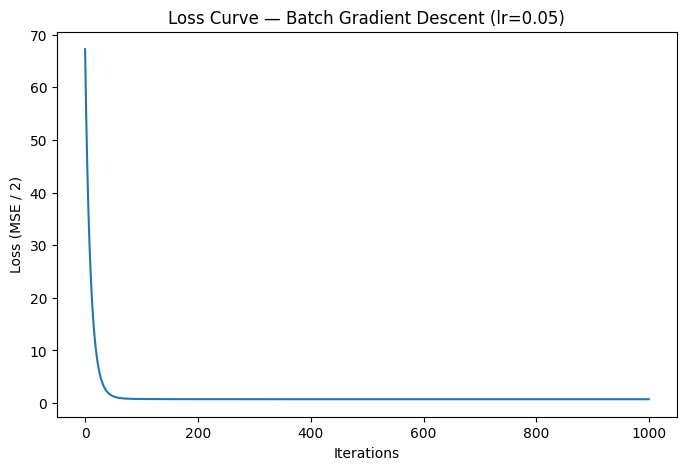

Final training loss: 0.7455654657349662


In [ ]:
# Step 9: Train the Model (Default Learning Rate)
theta_final, cost_history = batch_gradient_descent(
    X_train_b, y_train, learning_rate=0.05, iterations=1000
)

plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE / 2)")
plt.title("Loss Curve — Batch Gradient Descent (lr=0.05)")
plt.show()

print("Final training loss:", cost_history[-1])

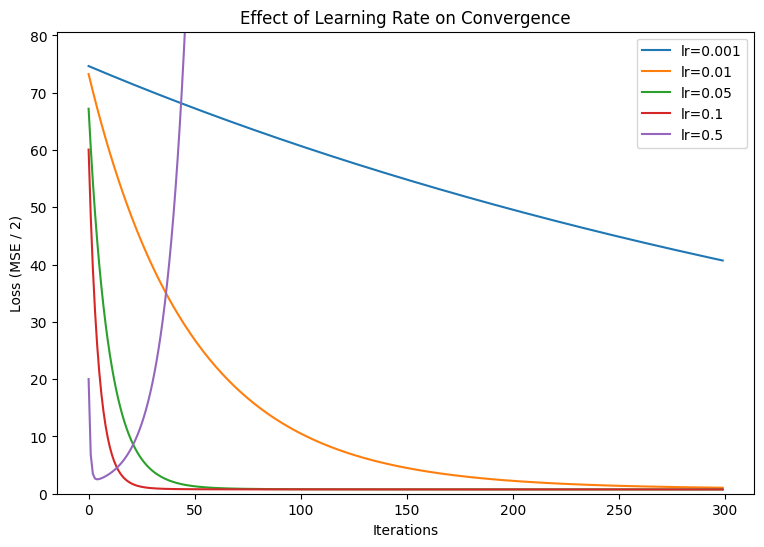

lr=0.001  final loss=40.7104
lr=0.01   final loss=1.0424
lr=0.05   final loss=0.7478
lr=0.1    final loss=0.7456
lr=0.5    final loss=2497027589854.1855


In [ ]:
# Step 10: Effect of Learning Rate
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
lr_histories = {}

plt.figure(figsize=(9, 6))
for lr in learning_rates:
    _, hist = batch_gradient_descent(X_train_b, y_train, learning_rate=lr, iterations=300)
    lr_histories[lr] = hist
    plt.plot(hist, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss (MSE / 2)")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.ylim(0, max(lr_histories[0.05][0] * 1.2, 50))
plt.show()

for lr in learning_rates:
    print(f"lr={lr:<6} final loss={lr_histories[lr][-1]:.4f}")

In [ ]:
# Step 11: Final Model and Predictions
theta_final, cost_history = batch_gradient_descent(
    X_train_b, y_train, learning_rate=0.05, iterations=2000
)

y_pred = X_test_b.dot(theta_final)

In [ ]:
# Step 12: Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R2 Score:", round(r2, 4))

Mean Absolute Error (MAE): 0.7651
Mean Squared Error (MSE): 1.4759
Root Mean Squared Error (RMSE): 1.2149
R2 Score: 0.8487


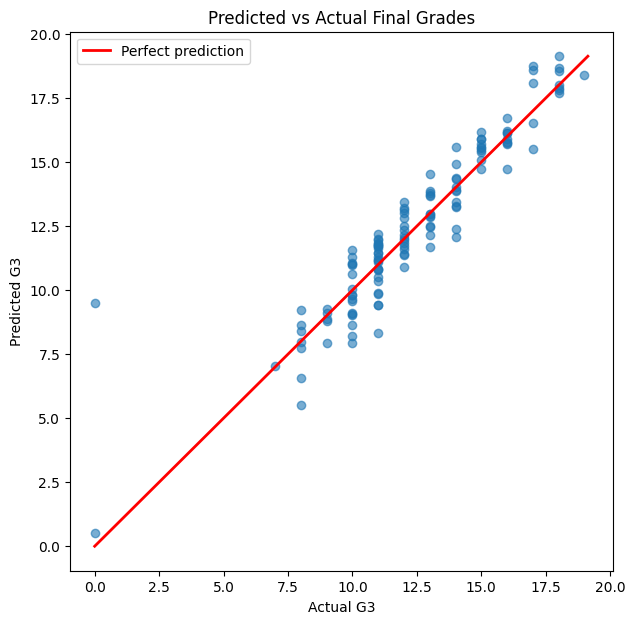

In [ ]:
# Step 13: Predicted vs Actual Grades
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linewidth=2, label="Perfect prediction")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Final Grades")
plt.legend()
plt.show()

In [ ]:
# Step 14: Prepare the Single-Feature Data
X_single = df[["G2"]].values
y_single = df["G3"].values.reshape(-1, 1)

scaler_single = StandardScaler()
X_single_scaled = scaler_single.fit_transform(X_single)

m_s = len(X_single_scaled)
X_single_bias = np.c_[np.ones((m_s, 1)), X_single_scaled]

print("X_single_bias shape:", X_single_bias.shape)

X_single_bias shape: (649, 2)


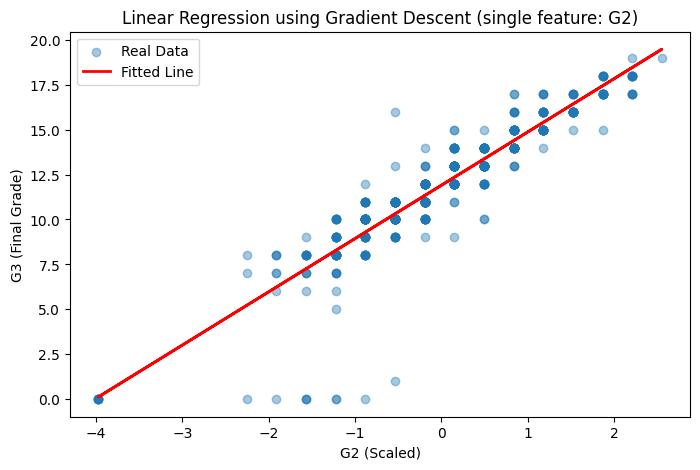

In [ ]:
# Step 15: Fit with Batch Gradient Descent and Plot the Regression Line
theta_demo, cost_demo = batch_gradient_descent(
    X_single_bias, y_single, learning_rate=0.1, iterations=500
)

plt.figure(figsize=(8, 5))
plt.scatter(X_single_scaled, y_single, alpha=0.4, label="Real Data")
plt.plot(X_single_scaled, X_single_bias.dot(theta_demo),
         color='red', linewidth=2, label="Fitted Line")
plt.xlabel("G2 (Scaled)")
plt.ylabel("G3 (Final Grade)")
plt.title("Linear Regression using Gradient Descent (single feature: G2)")
plt.legend()
plt.show()

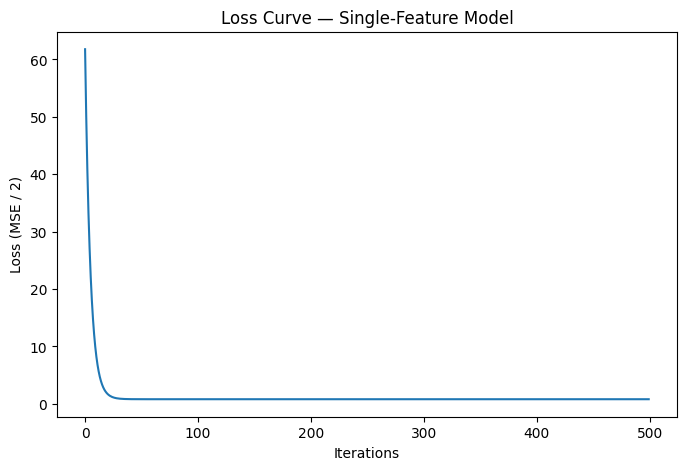

In [ ]:
# Step 16: Loss Curve for the Single-Feature Model
plt.figure(figsize=(8, 5))
plt.plot(cost_demo)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE / 2)")
plt.title("Loss Curve — Single-Feature Model")
plt.show()

In [ ]:
# Step 17: Mini-Batch and Stochastic Gradient Descent (for comparison)
def mini_batch_gradient_descent(X, y, learning_rate=0.1, epochs=100, batch_size=32):
    m, n = X.shape
    theta = np.zeros((n, 1))
    history = [theta.flatten().copy()]
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            predictions = X_batch.dot(theta)
            gradients = (1 / len(y_batch)) * X_batch.T.dot(predictions - y_batch)
            theta = theta - learning_rate * gradients

        history.append(theta.flatten().copy())
        cost_history.append(compute_cost(theta, X, y))

    return theta, np.array(history), cost_history


def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    m, n = X.shape
    theta = np.zeros((n, 1))
    history = [theta.flatten().copy()]
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(m):
            xi = X_shuffled[i:i + 1]
            yi = y_shuffled[i:i + 1]
            prediction = xi.dot(theta)
            gradient = xi.T.dot(prediction - yi)
            theta = theta - learning_rate * gradient

        history.append(theta.flatten().copy())
        cost_history.append(compute_cost(theta, X, y))

    return theta, np.array(history), cost_history


def batch_gradient_descent_with_history(X, y, learning_rate=0.1, epochs=100):
    m, n = X.shape
    theta = np.zeros((n, 1))
    history = [theta.flatten().copy()]
    cost_history = []

    for epoch in range(epochs):
        predictions = X.dot(theta)
        gradients = (1 / m) * X.T.dot(predictions - y)
        theta = theta - learning_rate * gradients
        history.append(theta.flatten().copy())
        cost_history.append(compute_cost(theta, X, y))

    return theta, np.array(history), cost_history

In [ ]:
theta_batch, history_batch, cost_batch = \
    batch_gradient_descent_with_history(X_single_bias, y_single, learning_rate=0.1, epochs=100)

theta_mini, history_mini, cost_mini = \
    mini_batch_gradient_descent(X_single_bias, y_single, learning_rate=0.1, epochs=100)

theta_sgd, history_sgd, cost_sgd = \
    stochastic_gradient_descent(X_single_bias, y_single, learning_rate=0.01, epochs=100)

In [ ]:
# Step 18: Cost Surface
theta0_vals = np.linspace(-10, 25, 100)
theta1_vals = np.linspace(-10, 25, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_temp = np.array([[T0[i, j]], [T1[i, j]]])
        J_vals[i, j] = compute_cost(theta_temp, X_single_bias, y_single)

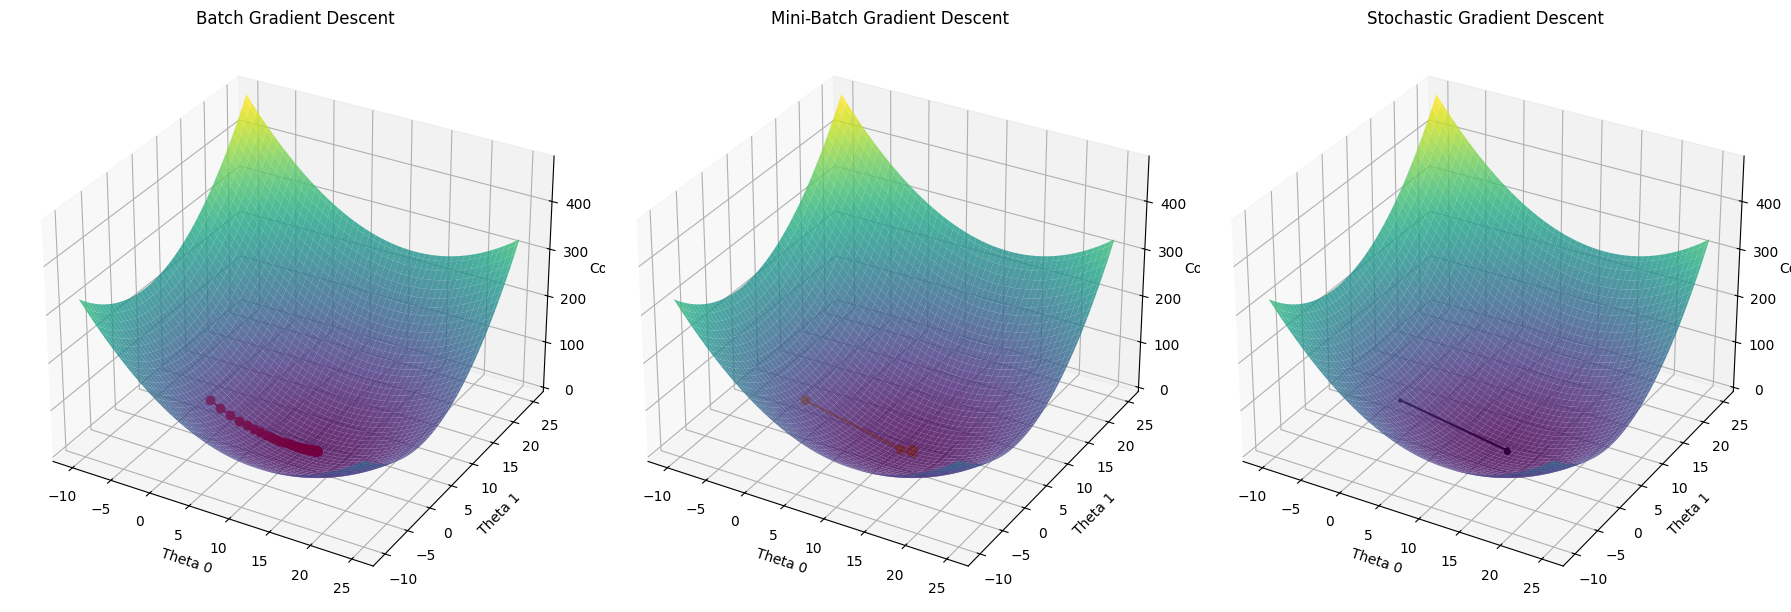

In [ ]:
# Step 19: 3D Visualization of the Optimization Paths
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax1.plot(history_batch[:, 0], history_batch[:, 1],
         [compute_cost(h.reshape(2, 1), X_single_bias, y_single) for h in history_batch],
         color='red', marker='o')
ax1.set_title("Batch Gradient Descent")
ax1.set_xlabel("Theta 0")
ax1.set_ylabel("Theta 1")
ax1.set_zlabel("Cost")

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax2.plot(history_mini[:, 0], history_mini[:, 1],
         [compute_cost(h.reshape(2, 1), X_single_bias, y_single) for h in history_mini],
         color='orange', marker='o')
ax2.set_title("Mini-Batch Gradient Descent")
ax2.set_xlabel("Theta 0")
ax2.set_ylabel("Theta 1")
ax2.set_zlabel("Cost")

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax3.plot(history_sgd[:, 0], history_sgd[:, 1],
         [compute_cost(h.reshape(2, 1), X_single_bias, y_single) for h in history_sgd],
         color='black', marker='o', markersize=2)
ax3.set_title("Stochastic Gradient Descent")
ax3.set_xlabel("Theta 0")
ax3.set_ylabel("Theta 1")
ax3.set_zlabel("Cost")

plt.tight_layout()
plt.show()

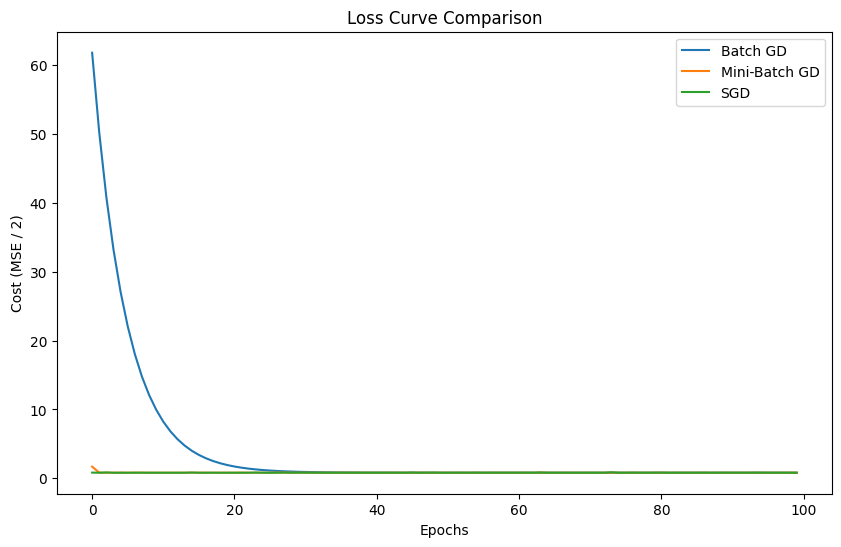

In [ ]:
# Step 20: Loss Curve Comparison
plt.figure(figsize=(10, 6))
plt.plot(cost_batch, label="Batch GD")
plt.plot(cost_mini, label="Mini-Batch GD")
plt.plot(cost_sgd, label="SGD")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE / 2)")
plt.title("Loss Curve Comparison")
plt.legend()
plt.show()

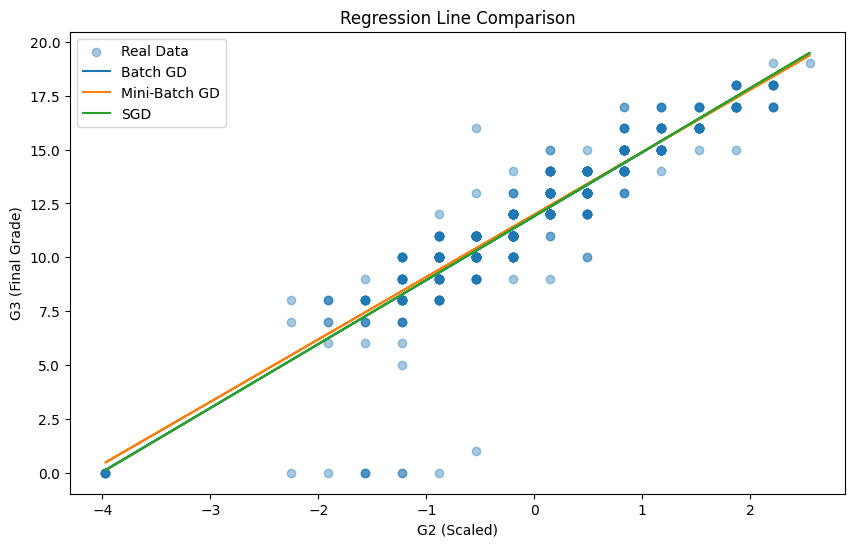

In [ ]:
# Step 21: Regression Line Comparison
plt.figure(figsize=(10, 6))
plt.scatter(X_single_scaled, y_single, alpha=0.4, label="Real Data")
plt.plot(X_single_scaled, X_single_bias.dot(theta_batch), label="Batch GD")
plt.plot(X_single_scaled, X_single_bias.dot(theta_mini), label="Mini-Batch GD")
plt.plot(X_single_scaled, X_single_bias.dot(theta_sgd), label="SGD")
plt.xlabel("G2 (Scaled)")
plt.ylabel("G3 (Final Grade)")
plt.title("Regression Line Comparison")
plt.legend()
plt.show()

In [ ]:
# Step 22: Final Parameters
print("==============================")
print("FINAL PARAMETERS (single-feature model, G2 -> G3)")
print("==============================")
print("\nBatch GD:", theta_batch.flatten())
print("Mini-Batch GD:", theta_mini.flatten())
print("Stochastic GD:", theta_sgd.flatten())